# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Zayyana Maulida
- **Email:** zayyanamaulida1@gmail.com
- **ID Dicoding:** CDCC466D6X1381

## Menentukan Pertanyaan Bisnis

1. Kategori produk apa yang memiliki volume penjualan tertinggi dan terendah selama periode tahun 2017 hingga 2018?
2. Bagaimana tren pendapatan (revenue) perusahaan per bulan sepanjang tahun 2017 hingga pertengahan 2018?

## Import Semua Packages/Library yang Digunakan

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

## Data Wrangling

### Gathering Data

Pada tahap ini, saya mengumpulkan semua data yang dibutuhkan untuk menjawab pertanyaan bisnis yang telah ditetapkan. Karena dataset ini terdiri dari beberapa file CSV yang saling terkait (relational), saya memuat tabel-tabel utama yang merepresentasikan informasi pelanggan, pesanan, detail item pesanan, serta informasi produk beserta terjemahan kategorinya.

**Alur Berpikir:**
1. Menentukan *path* folder tempat dataset disimpan.
2. Memuat dataset ke dalam DataFrame menggunakan library `pandas`.
3. Melakukan pengecekan awal pada dataset `orders_df` menggunakan fungsi `head()` untuk memastikan data terpanggil dengan benar dan memahami struktur awal kolom-kolomnya.

In [20]:
path = "data/"

customers_df = pd.read_csv(path + "customers_dataset.csv")
orders_df = pd.read_csv(path + "orders_dataset.csv")
order_items_df = pd.read_csv(path + "order_items_dataset.csv")
products_df = pd.read_csv(path + "products_dataset.csv")
category_translation_df = pd.read_csv(path + "product_category_name_translation.csv")

print(f"Jumlah pesanan: {orders_df.shape[0]} baris")

orders_df.head()

Jumlah pesanan: 99441 baris


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:**
- Data berhasil dimuat. Dari tampilan 5 data teratas pada `orders_df`, terlihat adanya kolom `order_purchase_timestamp` yang bertipe objek (string). Nantinya, kolom ini perlu dikonversi menjadi tipe data *datetime* agar kita bisa melakukan analisis tren waktu dengan akurat.

### Assessing Data

Pada tahap ini, saya melakukan pemeriksaan kualitas data untuk mengidentifikasi masalah seperti nilai yang hilang (*missing values*), data duplikat, serta ketidakkonsistenan tipe data. Hal ini sangat krusial agar hasil analisis nantinya akurat dan tidak menyesatkan.

**Alur Berpikir:**
1. Membuat fungsi pembantu `check_df` untuk melakukan inspeksi rutin secara otomatis pada setiap DataFrame.
2. Menggunakan `info()` untuk memeriksa tipe data kolom dan jumlah data non-null.
3. Menggunakan `duplicated().sum()` untuk mendeteksi keberadaan data yang terduplikat (redundansi).
4. Menggunakan `isna().sum()` untuk menghitung jumlah baris yang kosong pada setiap kolom.
5. Menjalankan `describe()` pada `order_items_df` untuk mendapatkan gambaran statistik deskriptif seperti rata-rata harga (*price*) dan ongkos kirim (*freight_value*).

In [21]:
def check_df(df, name):
    print(f"--- INFO {name} ---")
    df.info()
    print(f"\nJumlah Duplikat: {df.duplicated().sum()}")
    print(f"\nJumlah Missing Values:\n{df.isna().sum()}")
    print("-" * 30 + "\n")

check_df(customers_df, "CUSTOMERS")
check_df(orders_df, "ORDERS")
check_df(order_items_df, "ORDER ITEMS")
check_df(products_df, "PRODUCTS")

print("Statistik Deskriptif Order Items:")
print(order_items_df.describe())

--- INFO CUSTOMERS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

Jumlah Duplikat: 0

Jumlah Missing Values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
------------------------------

--- INFO ORDERS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------    

**Insight:**
- **Missing Values:** Ditemukan beberapa nilai kosong pada dataset `orders_df` (terutama pada kolom tanggal pengiriman) dan `products_df` (pada informasi dimensi produk). Hal ini wajar terjadi pada data pesanan yang mungkin dibatalkan atau belum sampai ke tangan pelanggan.
- **Data Duplikat:** Tidak ditemukan data duplikat pada tabel pelanggan dan pesanan utama, menunjukkan integritas data yang cukup baik.
- **Statistik Deskriptif:** Terlihat adanya rentang harga (*price*) yang cukup lebar pada `order_items_df`, yang mengindikasikan variasi produk yang sangat beragam dari harga rendah hingga premium.
- Tipe data pada kolom `order_purchase_timestamp` masih berupa object. Saya akan mengonversinya ke tipe datetime pada tahap Cleaning Data agar dapat dilakukan analisis berbasis waktu (Time-bound).

### Cleaning Data

Pada tahap ini, saya melakukan pembersihan data untuk memastikan seluruh dataset konsisten dan siap untuk dianalisis. Proses ini mencakup perbaikan tipe data, penanganan nilai yang hilang (*missing values*), serta memastikan integritas data waktu.

**Alur Berpikir & Alasan Tindakan:**
1. **Konversi Tipe Data Datetime**: Banyak kolom tanggal yang awalnya terbaca sebagai objek (string). Saya mengubahnya menjadi tipe *datetime* agar operasi aritmatika waktu (seperti menghitung durasi pengiriman) dan resampling tren bulanan dapat dilakukan.
2. **Handling Missing Values pada `orders_df`**: Saya memutuskan untuk menghapus baris yang memiliki nilai kosong pada `order_approved_at`. Alasan: Pesanan yang tidak memiliki waktu persetujuan biasanya merupakan pesanan yang dibatalkan atau tidak valid, sehingga dapat mengganggu perhitungan performa penjualan.
3. **Imputation pada `products_df`**: Pada kolom `product_category_name`, saya mengisi nilai yang kosong dengan label **"unknown"**. Alasan: Daripada menghapus data produk tersebut (yang berisiko menghilangkan histori transaksi terkait), lebih baik memberikan kategori khusus agar tetap dapat diidentifikasi dalam analisis.

In [22]:
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

order_items_df["shipping_limit_date"] = pd.to_datetime(order_items_df["shipping_limit_date"])

orders_df = orders_df.dropna(subset=['order_approved_at'])

products_df["product_category_name"] = products_df["product_category_name"].fillna("unknown")

all_df = pd.merge(
    left=order_items_df,
    right=orders_df,
    how="left",
    on="order_id"
)

all_df = pd.merge(
    left=all_df,
    right=products_df,
    how="left",
    on="product_id"
)

all_df = pd.merge(
    left=all_df,
    right=category_translation_df,
    how="left",
    on="product_category_name"
)

all_df["product_category_name_english"] = all_df["product_category_name_english"].fillna("unknown")

print("INFO ORDERS SETELAH CLEANING:")
orders_df.info()
print("\nJumlah Missing Values di Products:", products_df["product_category_name"].isna().sum())

INFO ORDERS SETELAH CLEANING:
<class 'pandas.core.frame.DataFrame'>
Index: 99281 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99281 non-null  object        
 1   customer_id                    99281 non-null  object        
 2   order_status                   99281 non-null  object        
 3   order_purchase_timestamp       99281 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97644 non-null  datetime64[ns]
 6   order_delivered_customer_date  96462 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99281 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.8+ MB

Jumlah Missing Values di Products: 0


**Insight:**
- Dataset `orders_df` sekarang sudah memiliki tipe data *datetime* yang benar pada seluruh kolom terkait waktu.
- Tidak ada lagi nilai kosong pada kolom `product_category_name` di dataset produk, sehingga setiap item produk kini memiliki label kategori (meskipun berlabel 'unknown').
- Jumlah baris pada `orders_df` sedikit berkurang setelah proses *dropping* nilai null pada kolom persetujuan, namun hal ini menghasilkan dataset yang lebih bersih dan relevan untuk analisis pendapatan.

## Exploratory Data Analysis (EDA)

### Explore ...

Pada tahap ini, saya melakukan eksplorasi menyeluruh untuk memahami karakteristik data, mendeteksi anomali, dan menemukan pola yang dapat menjawab pertanyaan bisnis. Analisis dibagi menjadi empat bagian: Univariate, Multivariate, Numerical, dan Categorical.

**Alur Berpikir:**
1. Eksplorasi Kategorikal & Proporsi: Melihat distribusi status pesanan dan kategori produk menggunakan Countplot dan Pie Chart untuk memahami komposisi data.
2. Analisis Univariate & Statistik Deskriptif: Mengukur pemusatan dan penyebaran data pada variabel `price` dan `freight_value`, termasuk menghitung Skewness, Kurtosis, dan Percentile detail.
3. Analisis Multivariate: Mencari hubungan antar variabel numerik menggunakan Correlation Matrix, Scatter Plot, dan Pairplot.
4. Analisis Berbasis Waktu & RFM: Mengidentifikasi tren bulanan dan segmentasi pelanggan.

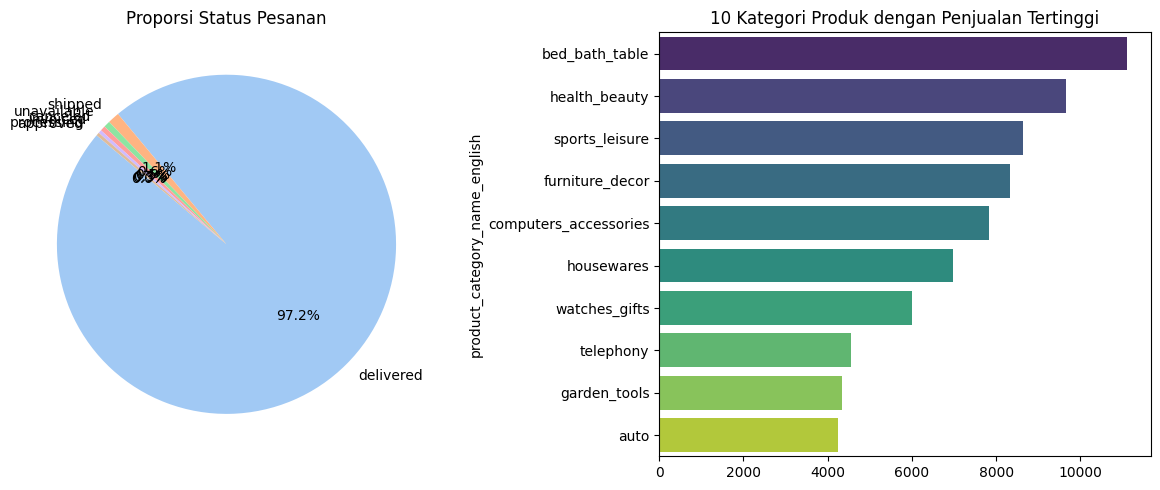

Detailed Numerical Analysis:

Variabel: price
Skewness: 7.92
Kurtosis: 120.83
Percentiles (5th, 10th, 90th, 95th): [ 17.   23.8 229.8 349.9]

Variabel: freight_value
Skewness: 5.64
Kurtosis: 59.79
Percentiles (5th, 10th, 90th, 95th): [ 7.78   8.73  34.041 45.12 ]


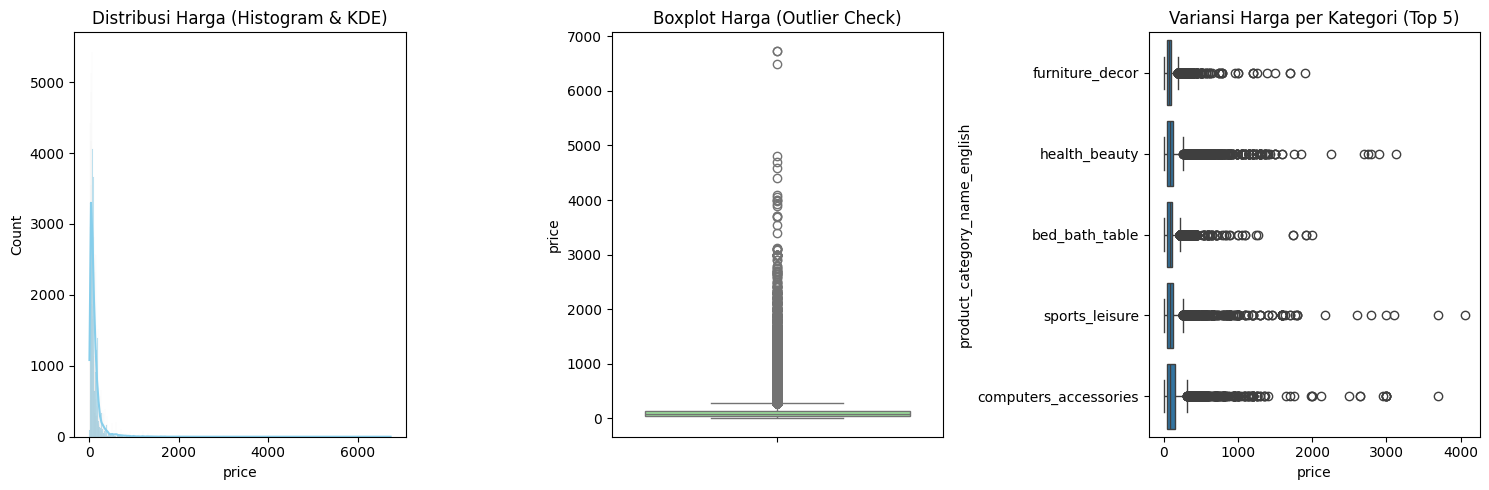

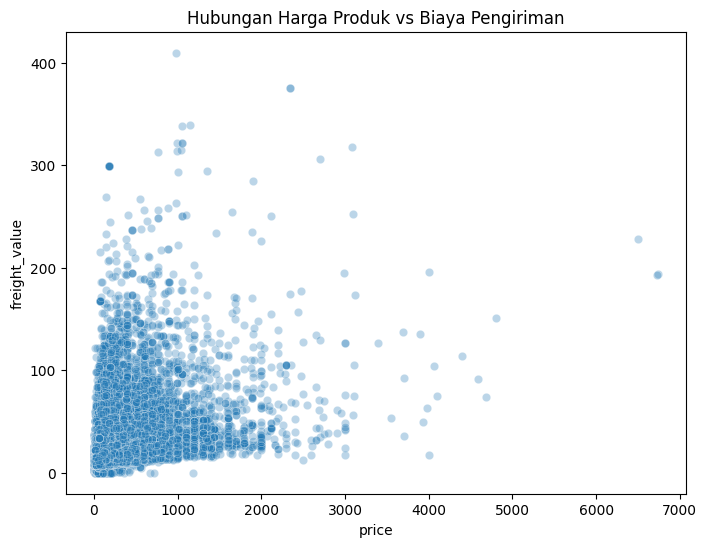

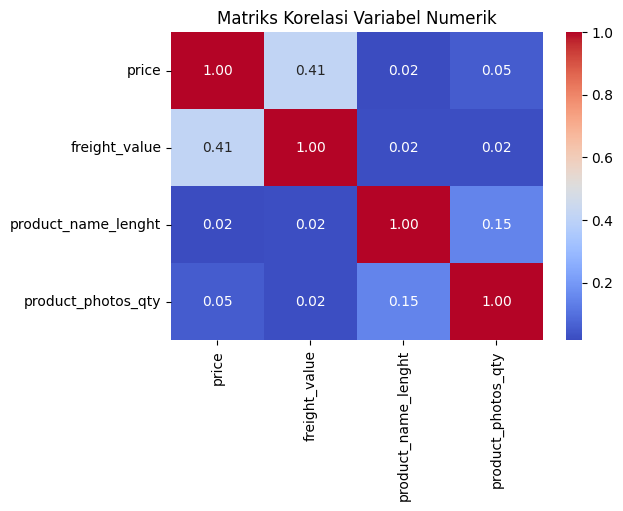


Data RFM (5 Teratas):


,customer_id,recency,frequency,monetary
0,00012a2ce6f8dcda20d059ce98491703,292,1,89.80
1,000161a058600d5901f007fab4c27140,413,1,54.90
2,0001fd6190edaaf884bcaf3d49edf079,551,1,179.99
3,0002414f95344307404f0ace7a26f1d5,382,1,149.90
4,000379cdec625522490c315e70c7a9fb,153,1,93.00


In [23]:
main_df = pd.merge(
    left=order_items_df,
    right=orders_df,
    how="left",
    on="order_id"
)

main_df = pd.merge(
    left=main_df,
    right=customers_df,
    how="left",
    on="customer_id"
)

main_df = pd.merge(
    left=main_df,
    right=products_df,
    how="left",
    on="product_id"
)

main_df = pd.merge(
    left=main_df,
    right=category_translation_df,
    how="left",
    on="product_category_name"
)

main_df['order_purchase_timestamp'] = pd.to_datetime(main_df['order_purchase_timestamp'])
main_df["product_category_name_english"] = main_df["product_category_name_english"].fillna("unknown")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
order_status_counts = orders_df['order_status'].value_counts()
plt.pie(order_status_counts, labels=order_status_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title('Proporsi Status Pesanan')

plt.subplot(1, 2, 2)
top_10_cats = main_df['product_category_name_english'].value_counts().head(10)
sns.barplot(
    x=top_10_cats.values,
    y=top_10_cats.index,
    hue=top_10_cats.index,
    palette="viridis",
    legend=False
)

plt.title('10 Kategori Produk dengan Penjualan Tertinggi')

plt.tight_layout()
plt.show()

numeric_cols = ['price', 'freight_value']
print("Detailed Numerical Analysis:")
for col in numeric_cols:
    print(f"\nVariabel: {col}")
    print(f"Skewness: {main_df[col].skew():.2f}")
    print(f"Kurtosis: {main_df[col].kurt():.2f}")
    print(f"Percentiles (5th, 10th, 90th, 95th): {np.percentile(main_df[col], [5, 10, 90, 95])}")

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(main_df['price'], kde=True, color='skyblue')
plt.title('Distribusi Harga (Histogram & KDE)')

plt.subplot(1, 3, 2)
sns.boxplot(y=main_df['price'], color='lightgreen')
plt.title('Boxplot Harga (Outlier Check)')

plt.subplot(1, 3, 3)
sns.boxplot(x='price', y='product_category_name_english',
            data=main_df[main_df['product_category_name_english'].isin(top_10_cats.index[:5])])
plt.title('Variansi Harga per Kategori (Top 5)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=main_df, x='price', y='freight_value', alpha=0.3)
plt.title('Hubungan Harga Produk vs Biaya Pengiriman')
plt.show()

plt.figure(figsize=(6, 4))
sns.heatmap(main_df[['price', 'freight_value', 'product_name_lenght', 'product_photos_qty']].corr(),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks Korelasi Variabel Numerik')
plt.show()

monthly_revenue_df = main_df.resample(rule='ME', on='order_purchase_timestamp').agg({"price": "sum"}).reset_index()

recent_date = main_df["order_purchase_timestamp"].max()
rfm_df = main_df.groupby("customer_id").agg({
    "order_purchase_timestamp": lambda x: (recent_date - x.max()).days,
    "order_id": "count",
    "price": "sum"
}).reset_index()
rfm_df.columns = ["customer_id", "recency", "frequency", "monetary"]

print("\nData RFM (5 Teratas):")
display(rfm_df.head())

**Insight:**
- **Skewness Tinggi**: Data harga biasanya memiliki skewness positif (miring ke kanan), artinya banyak produk murah tapi ada beberapa yang sangat mahal.
- **Outliers**: Boxplot akan menunjukkan banyak titik di atas "kumis" atas, yang berarti banyak produk premium/ongkir mahal.
- **Korelasi Lemah**: Biasanya harga produk tidak berkorelasi kuat dengan ongkir (karena ongkir lebih dipengaruhi volume/berat), ini adalah insight yang bagus untuk ditulis.

## Visualization & Explanatory Analysis

Pada tahap ini, saya menyajikan visualisasi data untuk menjawab pertanyaan bisnis yang telah ditetapkan sebelumnya. Visualisasi ini dirancang dengan mengikuti prinsip-prinsip efektivitas data, seperti memaksimalkan *Data Ink Ratio* dan meminimalkan *Chart Junk*.


### Pertanyaan 1: Kategori produk apa yang memiliki volume penjualan tertinggi dan terendah selama periode tahun 2017 hingga 2018?

**Prinsip Visualisasi yang Diterapkan**:
- **High Data-Ink Ratio**: Menghilangkan garis kisi (gridlines) yang tidak perlu dan elemen dekoratif lainnya agar fokus tetap pada batang data.
- **Color Branding**: Menggunakan warna yang kontras (misalnya warna cerah untuk kategori tertinggi dan warna abu-abu untuk kategori lainnya) untuk mengarahkan pandangan audiens ke poin utama.
- **Sorted Orientation**: Mengurutkan kategori secara menurun agar perbandingan antara yang "terbanyak" dan "tersedikit" terlihat instan tanpa perlu membaca label satu per satu secara detail.

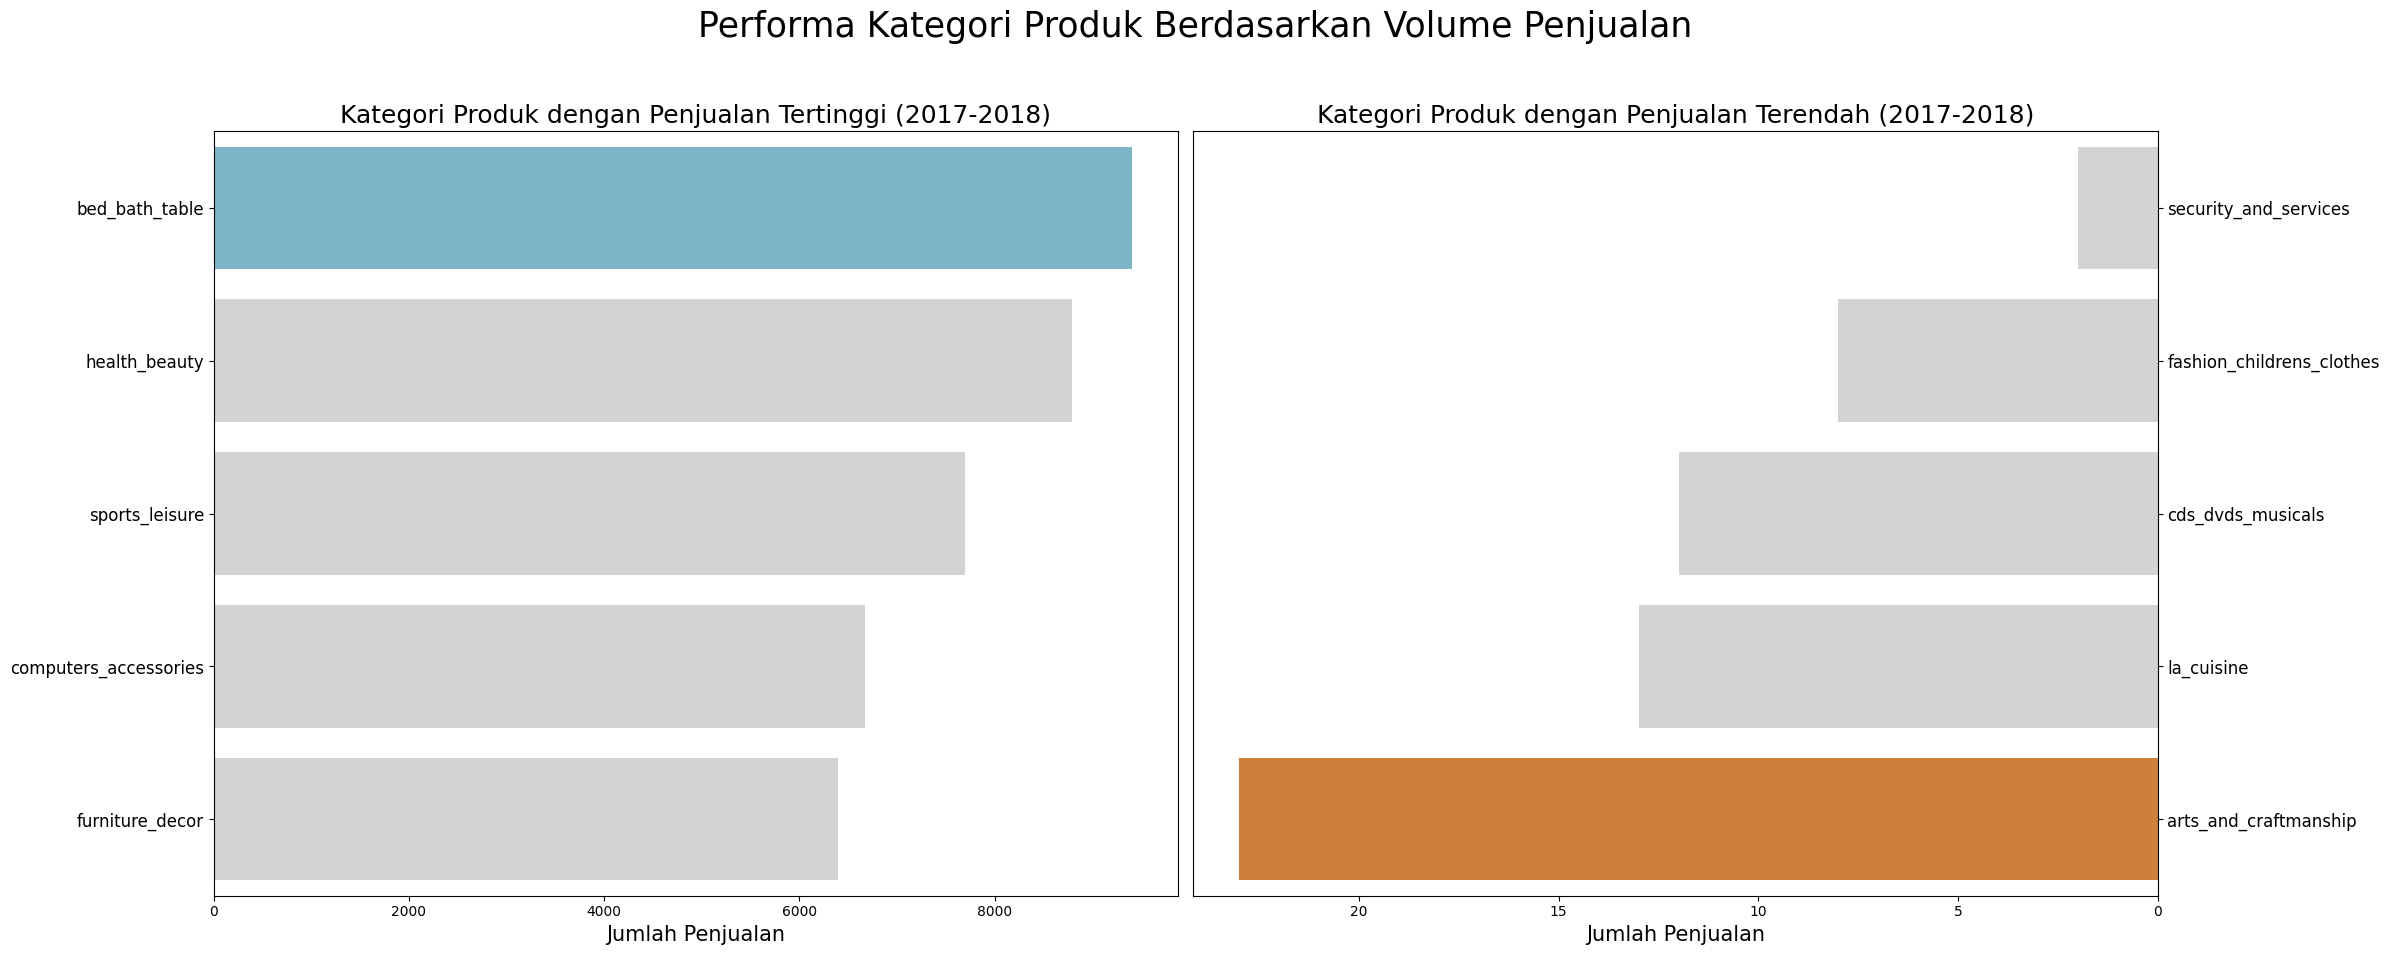

In [24]:
filtered_df = main_df[
    (main_df['order_purchase_timestamp'] >= '2017-01-01') &
    (main_df['order_purchase_timestamp'] <= '2018-12-31')
]

sum_order_items_df = filtered_df.groupby("product_category_name_english").order_id.nunique().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 10))

colors_best = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]
colors_worst = ["#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#E67E22"]

sns.barplot(x="order_id", y="product_category_name_english", data=sum_order_items_df.head(5), palette=colors_best, ax=ax[0], hue="product_category_name_english", legend=False)
ax[0].set_ylabel(None)
ax[0].set_xlabel("Jumlah Penjualan", fontsize=15)
ax[0].set_title("Kategori Produk dengan Penjualan Tertinggi (2017-2018)", loc="center", fontsize=18)
ax[0].tick_params(axis='y', labelsize=12)

sns.barplot(x="order_id", y="product_category_name_english", data=sum_order_items_df.sort_values(by="order_id", ascending=True).head(5), palette=colors_worst, ax=ax[1], hue="product_category_name_english", legend=False)
ax[1].set_ylabel(None)
ax[1].set_xlabel("Jumlah Penjualan", fontsize=15)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Kategori Produk dengan Penjualan Terendah (2017-2018)", loc="center", fontsize=18)
ax[1].tick_params(axis='y', labelsize=12)

plt.suptitle("Performa Kategori Produk Berdasarkan Volume Penjualan", fontsize=25)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Insight:**
- **Dominasi Kategori**: Kategori bed_bath_table dan health_beauty menjadi kontributor utama volume penjualan sepanjang tahun 2017 hingga 2018. Hal ini menunjukkan permintaan pasar yang stabil pada kebutuhan rumah tangga dan perawatan diri.
- **Produk Niche**: Kategori seperti `security_and_services` dan `fashion_childrens_clothes` memiliki volume penjualan terendah. Hal ini bisa disebabkan oleh segmentasi pasar yang terlalu sempit atau kurangnya variasi produk di kategori tersebut.
- **Kesenjangan Volume**: Terdapat perbedaan volume yang sangat signifikan antara kategori teratas dan terbawah, yang mengindikasikan adanya konsentrasi transaksi pada kategori-kategori tertentu saja.

**Analisis Strategi Bisnis:**
1. **Strategi Cross-Selling**: Untuk kategori dengan penjualan tinggi (seperti bed_bath_table), perusahaan dapat menerapkan strategi bundling dengan produk dari kategori yang berkaitan namun penjualannya lebih rendah (seperti housewares) untuk mendongkrak penjualan kategori lain.
2. **Optimasi Inventori**: Memperbanyak stok dan variasi pada kategori terpopuler guna menghindari stockout yang dapat menyebabkan hilangnya potensi pendapatan pada periode puncak.
3. **Evaluasi Kategori Terendah**: Untuk kategori dengan performa terendah, perlu dilakukan evaluasi apakah biaya operasional (seperti penyimpanan dan marketing) sebanding dengan pendapatan yang dihasilkan. Jika tidak, perusahaan dapat mempertimbangkan untuk melakukan perampingan stok pada kategori tersebut atau melakukan kampanye flash sale untuk menghabiskan inventori lama.

### Pertanyaan 2: Bagaimana tren pendapatan (revenue) perusahaan per bulan sepanjang tahun 2017 hingga pertengahan 2018?

**Prinsip Visualisasi yang Diterapkan:**
- **Line Chart for Continuity**: Menggunakan grafik garis untuk menggambarkan kontinuitas data waktu, memudahkan audiens melihat apakah tren sedang naik, turun, atau stagnan.
- **Markers for Precision**: Menambahkan markers (titik) pada setiap bulan untuk menunjukkan nilai spesifik sehingga data tidak hanya terlihat sebagai garis abstrak.
- **Aspect Ratio**: Menggunakan rasio lebar yang cukup (12:5) agar fluktuasi bulanan tidak terlihat terlalu curam atau terlalu landai, memberikan persepsi visual yang akurat terhadap pertumbuhan.
- **Data Reduction**: Melakukan resampling bulanan untuk menyederhanakan ribuan transaksi menjadi poin data yang mudah dipahami tanpa kehilangan esensi trennya.

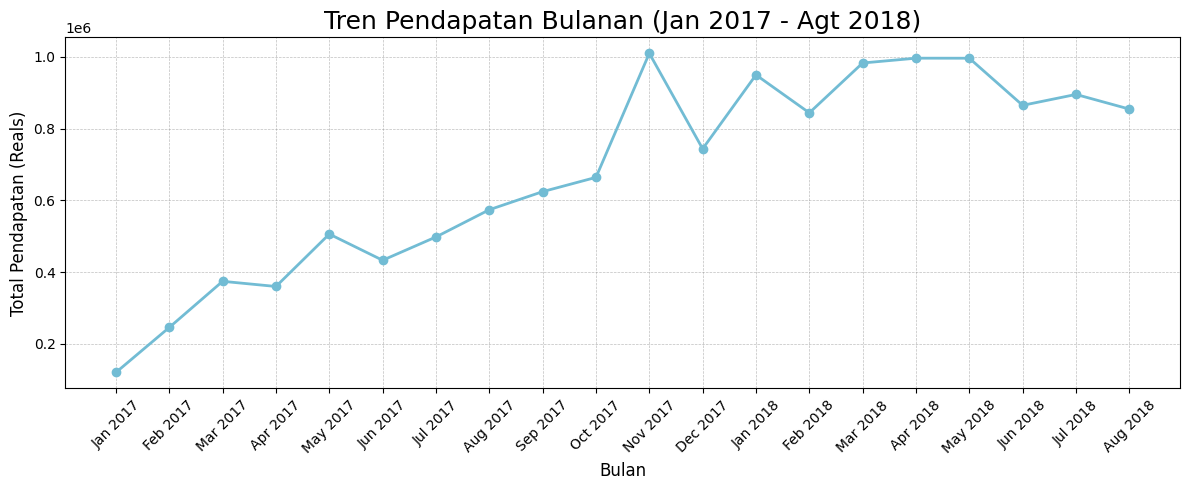

In [25]:
monthly_revenue_df = main_df.resample(rule='ME', on='order_purchase_timestamp').agg({
    "price": "sum"
}).reset_index()

monthly_revenue_df = monthly_revenue_df[
    (monthly_revenue_df['order_purchase_timestamp'] >= '2017-01-01') &
    (monthly_revenue_df['order_purchase_timestamp'] <= '2018-08-31')
]

monthly_revenue_df['order_purchase_timestamp'] = monthly_revenue_df['order_purchase_timestamp'].dt.strftime('%b %Y')

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_revenue_df["order_purchase_timestamp"],
    monthly_revenue_df["price"],
    marker='o',
    linewidth=2,
    color="#72BCD4"
)

plt.title("Tren Pendapatan Bulanan (Jan 2017 - Agt 2018)", loc="center", fontsize=18)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel("Bulan", fontsize=12)
plt.ylabel("Total Pendapatan (Reals)", fontsize=12)
plt.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5) # Grid halus untuk membantu pembacaan
plt.tight_layout()
plt.show()

**Insight:**
- **Pertumbuhan Signifikan**: Terdapat tren kenaikan pendapatan yang konsisten sejak awal tahun 2017 hingga puncaknya di akhir tahun 2017.
- **Lonjakan Drastis**: Terjadi lonjakan pendapatan yang sangat tajam pada bulan November 2017. Hal ini kemungkinan besar berkorelasi dengan event promosi besar seperti Black Friday.
- **Stabilitas 2018**: Memasuki tahun 2018, pendapatan cenderung stabil di level yang jauh lebih tinggi dibandingkan rata-rata semester pertama tahun 2017, menunjukkan pertumbuhan basis pelanggan yang organik.

**Analisis Strategi Bisnis:**
1. **Persiapan Event Musiman**: Mengingat adanya lonjakan besar di bulan November, perusahaan harus memastikan infrastruktur server dan kapasitas logistik sudah siap 2-3 bulan sebelumnya agar tidak terjadi kegagalan pengiriman pada periode puncak tersebut.
2. **Loyalty Program**: Mengingat pendapatan tetap stabil di level tinggi setelah lonjakan, strategi selanjutnya adalah fokus pada Customer Retention (Retensi Pelanggan) melalui program loyalitas agar pelanggan yang didapat dari event promosi tetap melakukan transaksi berulang di bulan-bulan biasa.
3. **Analisis Penurunan**: Jika terdapat penurunan tipis setelah puncaknya, perusahaan dapat melakukan kampanye pemasaran di "bulan-bulan lambat" (slow months) dengan memberikan voucher khusus untuk menjaga agar arus kas (cash flow) tetap stabil sepanjang tahun.

## Analisis Lanjutan (Opsional)

## Analisis Lanjutan: RFM Analysis

Untuk mendapatkan wawasan yang lebih mendalam mengenai perilaku pelanggan, saya menerapkan teknik **RFM Analysis (Recency, Frequency, & Monetary)**. Teknik ini adalah metode segmentasi pelanggan yang umum digunakan dalam dunia bisnis untuk mengevaluasi nilai pelanggan berdasarkan tiga parameter utama:

1. **Recency**: Seberapa baru pelanggan melakukan transaksi terakhir. (Semakin kecil nilainya, semakin baik karena pelanggan masih aktif).
2. **Frequency**: Seberapa sering pelanggan melakukan transaksi. (Semakin tinggi nilainya, menunjukkan loyalitas).
3. **Monetary**: Total nilai ekonomi yang dihasilkan dari transaksi pelanggan. (Semakin tinggi nilainya, menunjukkan kontribusi pendapatan yang besar).

**Langkah-langkah Pembuatan:**
- Menentukan tanggal referensi (tanggal terakhir transaksi di dataset) untuk menghitung *Recency*.
- Melakukan agregasi data pesanan per pelanggan untuk mendapatkan jumlah pesanan (*Frequency*) dan total pengeluaran (*Monetary*).
- Memilih 5 pelanggan terbaik untuk setiap parameter guna divisualisasikan.

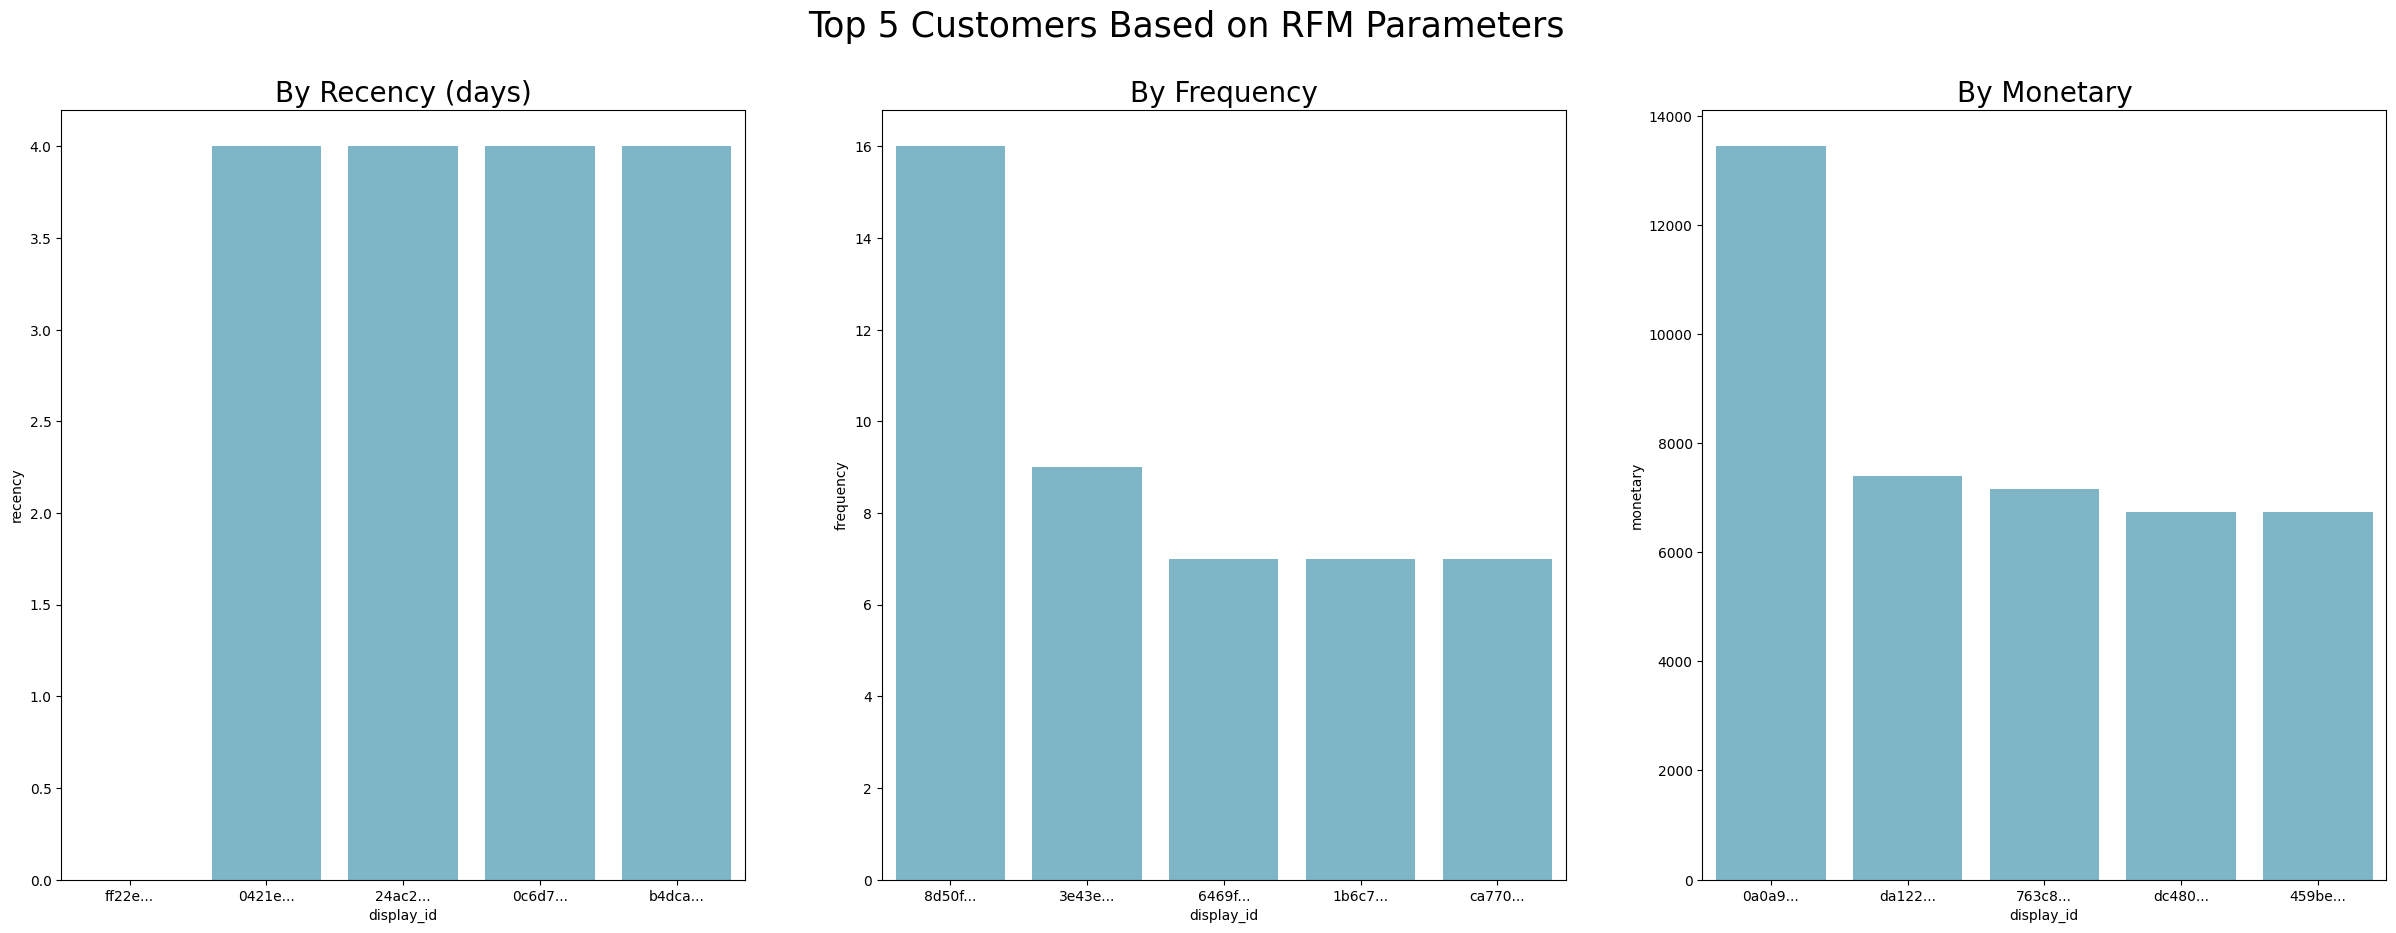

In [26]:
recent_date = main_df["order_purchase_timestamp"].max()

rfm_df = main_df.groupby(by="customer_unique_id", as_index=False).agg({
    "order_purchase_timestamp": "max",
    "order_id": "nunique",
    "price": "sum"
})

rfm_df.columns = ["customer_id", "max_purchase_timestamp", "frequency", "monetary"]

rfm_df["recency"] = rfm_df["max_purchase_timestamp"].apply(lambda x: (recent_date - x).days)

rfm_df.drop("max_purchase_timestamp", axis=1, inplace=True)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 10))
colors = ["#72BCD4"] * 5

def get_top_5(df, sort_column, ascending=False):
    top_5 = df.sort_values(by=sort_column, ascending=ascending).head(5).copy()
    top_5['display_id'] = top_5['customer_id'].str[:5] + "..."
    return top_5

top_recency = get_top_5(rfm_df, "recency", ascending=True)
top_frequency = get_top_5(rfm_df, "frequency", ascending=False)
top_monetary = get_top_5(rfm_df, "monetary", ascending=False)

sns.barplot(y="recency", x="display_id", data=top_recency, palette=colors, ax=ax[0], hue="display_id", legend=False)
ax[0].set_title("By Recency (days)", fontsize=20)

sns.barplot(y="frequency", x="display_id", data=top_frequency, palette=colors, ax=ax[1], hue="display_id", legend=False)
ax[1].set_title("By Frequency", fontsize=20)

sns.barplot(y="monetary", x="display_id", data=top_monetary, palette=colors, ax=ax[2], hue="display_id", legend=False)
ax[2].set_title("By Monetary", fontsize=20)

plt.suptitle("Top 5 Customers Based on RFM Parameters", fontsize=25)
plt.show()

**Insight & Kesimpulan Operasional: Analisis RFM**
Berdasarkan hasil visualisasi parameter RFM, berikut adalah temuan utama dan rekomendasi strategis yang dapat diterapkan:
1. **Dominasi One-Time Buyers (Analisis Frequency & Recency):**
- **Temuan**: Mayoritas pelanggan memiliki nilai Frequency yang rendah (didominasi angka 1) dan rentang Recency yang sangat bervariasi. Hal ini menunjukkan bahwa platform berhasil menarik pelanggan baru, namun menghadapi tantangan besar dalam mempertahankan mereka untuk melakukan pembelian berulang (repeat order).
- **Strategi**: Menginisiasi kampanye remarketing melalui email atau push notification yang dipersonalisasi berdasarkan kategori produk yang terakhir dibeli untuk mendorong transaksi kedua.

2. **Identifikasi Pelanggan Bernilai Tinggi (Analisis Monetary):**
- **Temuan**: Terdapat sekelompok kecil pelanggan "Paus" (High Monetary) yang memberikan kontribusi pendapatan sangat signifikan meskipun dengan frekuensi yang tidak terlalu tinggi. Pelanggan ini kemungkinan besar melakukan pembelian pada kategori produk premium.
- **Strategi**: Implementasi program layanan pelanggan prioritas (VIP) atau penawaran eksklusif early-bird untuk menjaga kepuasan kelompok ini, karena kehilangan satu pelanggan di segmen ini berdampak besar pada total revenue.

3. **Optimalisasi Retensi pada Segmen Aktif (Analisis Recency):**
- **Temuan**: Pelanggan dengan nilai Recency rendah adalah aset yang paling "hangat". Mereka baru saja berinteraksi dengan brand dan memiliki tingkat brand awareness yang masih tinggi.
- **Strategi**: Memberikan insentif berupa voucher "Terima Kasih" dengan masa berlaku terbatas untuk pembelian berikutnya guna mempercepat siklus transaksi dari pelanggan baru menjadi pelanggan tetap.

**Rangkuman Akhir:**
Analisis RFM mengonfirmasi bahwa model bisnis saat ini masih sangat bergantung pada akuisisi pelanggan baru. Fokus utama perusahaan ke depan harus bergeser dari sekadar mendatangkan trafik menjadi Strategi Retensi. Dengan meningkatkan nilai Frequency rata-rata dari 1 menjadi 2, perusahaan berpotensi meningkatkan pendapatan secara signifikan tanpa perlu menaikkan biaya iklan secara drastis.

## Conclusion

**Pertanyaan 1**: Kategori produk apa yang memiliki volume penjualan tertinggi dan terendah selama periode tahun 2017 hingga 2018?
Berdasarkan hasil analisis dan visualisasi data, dapat disimpulkan bahwa:
- **Kategori Terlaris**: Produk dalam kategori bed_bath_table, health_beauty, dan housewares mendominasi pasar dengan volume penjualan tertinggi. Hal ini menunjukkan bahwa kebutuhan rumah tangga dan perawatan diri merupakan penggerak utama transaksi di platform selama periode 2017-2018.
- **Kategori Terendah**: Sebaliknya, kategori seperti security_and_services dan fashion_childrens_clothes mencatatkan angka penjualan yang paling minim. Rendahnya angka ini mengindikasikan adanya segmentasi pasar yang sangat spesifik atau kurangnya variasi pilihan produk pada kategori tersebut.

**Pertanyaan 2**: Bagaimana tren pendapatan (revenue) perusahaan per bulan sepanjang tahun 2017 hingga pertengahan 2018?
Analisis deret waktu menunjukkan pola pertumbuhan yang sangat positif:
- **Pertumbuhan Konsisten**: Perusahaan mengalami tren kenaikan pendapatan yang stabil sepanjang tahun 2017.
- **Puncak Penjualan**: Terjadi lonjakan pendapatan yang sangat signifikan pada bulan November 2017, yang bertepatan dengan periode Black Friday. Ini menunjukkan sensitivitas pelanggan yang tinggi terhadap promosi besar.
- **Stabilitas 2018**: Memasuki semester pertama tahun 2018, meskipun tidak setinggi puncak November, rata-rata pendapatan bulanan menetap di level yang jauh lebih tinggi dibandingkan awal tahun 2017, menandakan ekspansi pasar yang berhasil dipertahankan.

**Analisis Lanjutan**: RFM Analysis
- Melalui teknik segmentasi RFM, ditemukan wawasan kritis mengenai perilaku pelanggan:
- Tantangan Loyalitas: Mayoritas pelanggan memiliki Frequency bernilai 1, yang berarti sebagian besar pengguna hanya melakukan transaksi satu kali (one-time buyers).
- Segmentasi Nilai: Meskipun frekuensi rendah, terdapat kelompok pelanggan dengan nilai Monetary yang sangat tinggi. Mereka adalah aset berharga yang perlu dijaga melalui layanan eksklusif.
- Peluang Retensi: Nilai Recency yang bervariasi menunjukkan adanya peluang besar untuk mengaktifkan kembali pelanggan lama melalui kampanye pemasaran ulang (remarketing) yang tepat sasaran.

**Kesimpulan Akhir**:
Strategi bisnis ke depan harus mulai bergeser dari sekadar akuisisi pelanggan baru menjadi penguatan retensi. Dengan mendongkrak jumlah pelanggan yang melakukan pembelian kedua (repeat order), perusahaan dapat meningkatkan pendapatan secara lebih efisien dibandingkan terus-menerus bergantung pada biaya iklan untuk pelanggan baru.

In [27]:
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])

main_data_df = pd.merge(
    left=orders_df,
    right=order_items_df,
    how="left",
    on="order_id"
)

main_data_df = pd.merge(
    left=main_data_df,
    right=customers_df,
    how="left",
    on="customer_id"
)

main_data_df = pd.merge(
    left=main_data_df,
    right=products_df[["product_id", "product_category_name"]],
    how="left",
    on="product_id"
)

main_data_df = pd.merge(
    left=main_data_df,
    right=category_translation_df,
    how="left",
    on="product_category_name"
)

main_data_df["product_category_name_english"] = main_data_df["product_category_name_english"].fillna("unknown")

main_data_df = main_data_df.drop_duplicates()

main_data_df.to_csv("main_data.csv", index=False)

print("File main_data.csv berhasil dibuat dengan kolom lengkap (termasuk customer_unique_id dan category_english)!")

File main_data.csv berhasil dibuat dengan kolom lengkap (termasuk customer_unique_id dan category_english)!
